In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # разделяет данные на обучающую и тестовую выборки
from sklearn.preprocessing import LabelEncoder, StandardScaler # преобразует категориальные признаки (текстовые значения) в числовые, нормализует/стандартизирует признаки
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # доля правильных ответов, матрица ошибок
from sklearn.feature_selection import mutual_info_classif # оценивает важность каждого признака
import torch
import torch.nn as nn # включает слои, функции активации, функции потерь
import torch.optim as optim # алг опт Adam
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
print("Датасет")

df = pd.read_csv('mushrooms.csv')
print(f"Размер датасета: {df.shape}") # кортеж - ко-во строк и столбцов
print(f"Первые 5 строк:\n{df.head()}\n")

Датасет
Размер датасета: (8124, 23)
Первые 5 строк:
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w    

EDA (разведочный анализ данных)

Целевая переменная (class)
class
e    4208
p    3916
Name: count, dtype: int64

Съедобные (e): 4208
Ядовитые (p): 3916


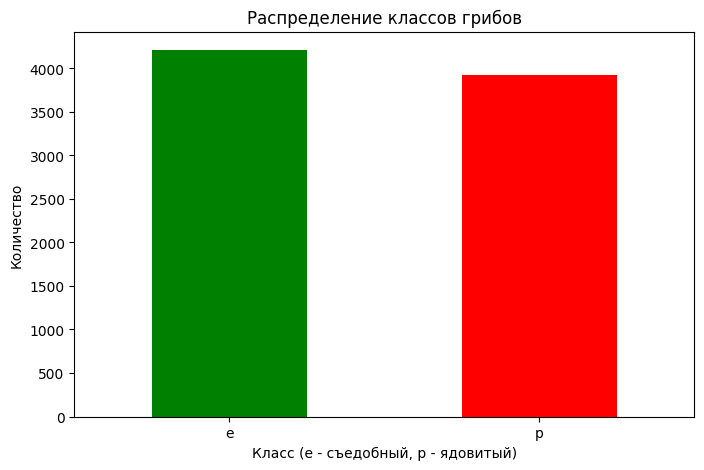

In [ ]:
# анализ целевой переменной
print("EDA (разведочный анализ данных)")
print("\nЦелевая переменная (class)")
print(df['class'].value_counts()) # обращается к колонке 'class' и считает ко-во уникальных знач
print(f"\nСъедобные (e): {df['class'].value_counts()['e']}")
print(f"Ядовитые (p): {df['class'].value_counts()['p']}")

# график распределения классов
plt.figure(figsize=(8, 5))
df['class'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Распределение классов грибов')
plt.xlabel('Класс (e - съедобный, p - ядовитый)')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()


In [ ]:
# Кодирование данных для анализа
# Целевую переменную кодируем LabelEncoder: e=0, p=1
le = LabelEncoder()

# изучает все уникальные значения в столбце и заменяет каждое значение числом
y = le.fit_transform(df['class'])

# Признаки кодируем через One-Hot Encoding (pd.get_dummies).
X = pd.get_dummies(df.drop('class', axis=1))
# axis=1 удаляет колонку, поэтому остаются только признаки


Сортироваанные признаки по важности
odor_n                        0.364342
odor_f                        0.239072
stalk-surface-above-ring_k    0.197951
gill-color_b                  0.191183
stalk-surface-below-ring_k    0.187373
                                ...   
stalk-color-above-ring_y      0.000000
ring-number_n                 0.000000
veil-color_y                  0.000000
ring-type_f                   0.000000
spore-print-color_y           0.000000
Length: 117, dtype: float64


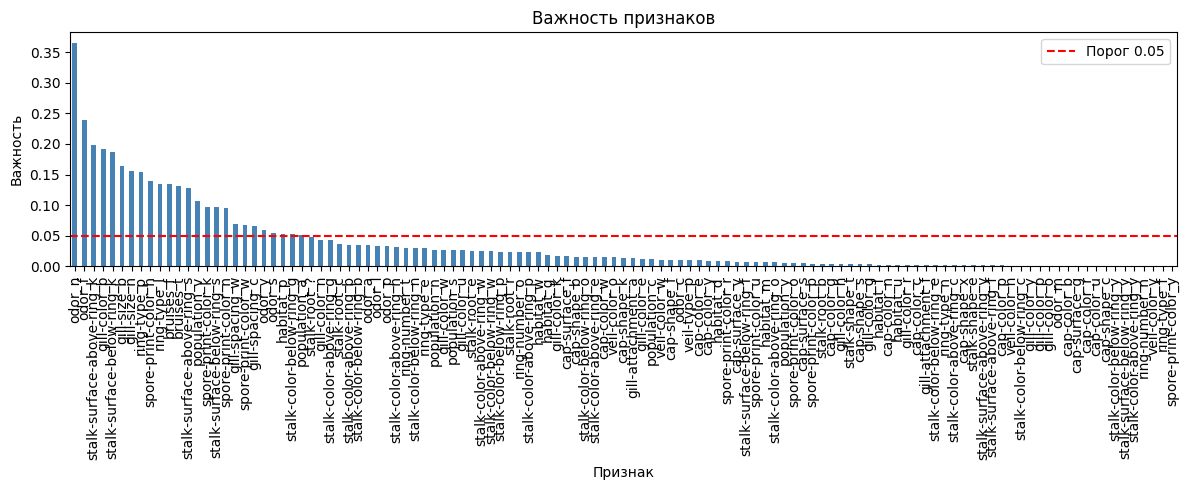


Отобрано признаков для обучения: 25
Отобранные признаки: ['odor_n', 'odor_f', 'stalk-surface-above-ring_k', 'gill-color_b', 'stalk-surface-below-ring_k', 'gill-size_b', 'gill-size_n', 'ring-type_p', 'spore-print-color_h', 'ring-type_l', 'bruises_f', 'bruises_t', 'stalk-surface-above-ring_s', 'population_v', 'spore-print-color_k', 'stalk-surface-below-ring_s', 'spore-print-color_n', 'gill-spacing_w', 'spore-print-color_w', 'gill-spacing_c', 'odor_y', 'odor_s', 'habitat_p', 'stalk-color-below-ring_g', 'population_a']


In [ ]:
# Вычисление важности признаков
mi_scores = mutual_info_classif(X, y) # показывает, насколько признак помогает предсказать класс
mi_scores = pd.Series(mi_scores, index=X.columns) # превращение массива чисел в удобный формат пандас
mi_scores = mi_scores.sort_values(ascending=False) # сортируем по убыванию

print("\nСортироваанные признаки по важности")
print(mi_scores)

plt.figure(figsize=(12, 5))
mi_scores.plot(kind='bar', color='steelblue')
plt.axhline(y=0.05, color='red', linestyle='--', label='Порог 0.05')
plt.title('Важность признаков')
plt.xlabel('Признак')
plt.ylabel('Важность')
plt.legend()
plt.tight_layout()
plt.show()

# Отбор значимых признаков
selected_features = mi_scores[mi_scores > 0.05].index.tolist()
print(f"\nОтобрано признаков для обучения: {len(selected_features)}")
print("Отобранные признаки:", selected_features)
X = X[selected_features]

## Подготовка данных для пайторч

In [ ]:
# тут делим
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)  # обуч-80, тест-20, ранд одинаковый, stratify сохраняет пропорции классов в обучающей и тестовой выборках (чтобы кол-во в съед и несъед было одинаковое в обоих выборках)

# StandardScaler приводит признаки в один диапозон
# fit только на train, чтобы не было утечки данных из теста (то есть чтобы заранее не было известно о тестовой выборке)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


# Преобразование в тензоры PyTorch

# Если есть видеокарта (cuda) — используем её, иначе процессор (cpu)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# FloatTensor — для признаков (дробные числа)
# LongTensor  — для меток классов (целые числа 0 или 1)
# .to(device)  — перемещаем тензор туда, где будет работать модель
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)



# TensorDataset связывает X и y в пары
# DataLoader нарезает датасет на батчи и подаёт их в модель по очереди
# batch_size=32 — модель обучается на 32 образцах за один шаг
# shuffle=True  — перемешиваем train каждую эпоху, чтобы модель не запоминала порядок данных
# shuffle=False — тест не перемешиваем, порядок не важен
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=32, shuffle=False)

print(f"\nОбучающая выборка: {X_train.shape[0]} образцов")
print(f"Тестовая выборка:  {X_test.shape[0]} образцов")
print(f"Признаков:         {X_train.shape[1]}")



Обучающая выборка: 6499 образцов
Тестовая выборка:  1625 образцов
Признаков:         25


# Определие моделей

In [ ]:
# количество столбцов (признаков) 2 столбец
input_size = X_train.shape[1]

# выход = вход × W + b (Смещение b (bias))
# bias дает модели сдвигать оценки независимо от входных данных, иначе граница между класса была всегда через 0

# Однослойный перцептрон
# self - дает то что каждая модель хранит свои собственные веса отдельно
class SingleLayerPerceptron(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc = nn.Linear(input_size, 2) #2 выхода и 23 входа (матрица весов размером 23×2)

    def forward(self, x):
        return self.fc(x)

# Многослойный перцептрон
class MultiLayerPerceptron(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1  = nn.Linear(input_size, 64) # матрица весов размером 23×64
        self.relu = nn.ReLU() # отвечает за нелинейное преобразование
        self.fc2  = nn.Linear(64, 2)

# показвает порядок проходения
    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.fc2(x)

# экземпляры моделей
model_single = SingleLayerPerceptron(input_size).to(device)
model_multi  = MultiLayerPerceptron(input_size).to(device)


In [ ]:
def train_model(model, optimizer, epochs, name):
    # CrossEntropyLoss подсчитывает, насколько прогноз отличается от правильного ответа
    criterion = nn.CrossEntropyLoss()
    train_accs, test_accs = [], []
    train_losses, test_losses = [], []

    # обучение
    for epoch in range(epochs):
        model.train() # включает режим обучения (веса обновляются)
        loss_sum, correct, total = 0, 0, 0
        for X_b, y_b in train_loader:
            optimizer.zero_grad()       # обнуляем градиенты чтобы не накапливались с прошлого шага
            out  = model(X_b)           # подаём 32 гриба, получаем 32 пары оценок
            loss = criterion(out, y_b)  # считает ошибку (предсказ-райт)
            loss.backward()             # обратный проход, считаем как каждый вес влияет на ошибку
            optimizer.step()            # обновляем веса в сторону уменьшения ошибки
            loss_sum += loss.item()
            correct  += (out.argmax(1) == y_b).sum().item()
            total    += y_b.size(0)

        train_losses.append(loss_sum / len(train_loader)) # средняя потеря за эпоху
        train_accs.append(100 * correct / total) # точность в процентах

        # оценка на тесте
        model.eval() # выключает режим обучения (веса не меняются)
        loss_sum, correct, total = 0, 0, 0
        with torch.no_grad():
            for X_b, y_b in test_loader:
                out  = model(X_b)
                loss = criterion(out, y_b)
                loss_sum += loss.item()
                correct  += (out.argmax(1) == y_b).sum().item()
                total    += y_b.size(0)

        test_losses.append(loss_sum / len(test_loader))
        test_accs.append(100 * correct / total)

        if (epoch + 1) % 1 == 0:
            print(f"[{name}] Эпоха {epoch+1}/{epochs} | "
                  f"Train Acc: {train_accs[-1]:.2f}% | Test Acc: {test_accs[-1]:.2f}%")

    return train_losses, test_losses, train_accs, test_accs


EPOCHS = 8

# Adam — оптимизатор, который сам подстраивает шаг обучения для каждого веса
print("\nОднослойный перцептрон")
opt_s = optim.Adam(model_single.parameters(), lr=0.01)
ls_s, lt_s, as_s, at_s = train_model(model_single, opt_s, EPOCHS, "Однослойный")

# lr=0.01 — скорость обучения, размер шага обновления весов
print("\nМногослойный перцептрон")
opt_m = optim.Adam(model_multi.parameters(), lr=0.001)
ls_m, lt_m, as_m, at_m = train_model(model_multi, opt_m, EPOCHS, "Многослойный")

# ls_s — обучение с потерями для однослойных моделей
# lt_s — тестирование с потерями для однослойных моделей
# as_s — обучение с точностью для однослойных моделей
# at_s — тестирование с точностью для однослойных моделей



Однослойный перцептрон
[Однослойный] Эпоха 1/8 | Train Acc: 94.25% | Test Acc: 96.74%
[Однослойный] Эпоха 2/8 | Train Acc: 96.91% | Test Acc: 96.98%
[Однослойный] Эпоха 3/8 | Train Acc: 97.32% | Test Acc: 96.92%
[Однослойный] Эпоха 4/8 | Train Acc: 97.31% | Test Acc: 96.92%
[Однослойный] Эпоха 5/8 | Train Acc: 97.23% | Test Acc: 97.35%
[Однослойный] Эпоха 6/8 | Train Acc: 97.32% | Test Acc: 97.23%
[Однослойный] Эпоха 7/8 | Train Acc: 97.54% | Test Acc: 97.05%
[Однослойный] Эпоха 8/8 | Train Acc: 97.32% | Test Acc: 97.35%

Многослойный перцептрон
[Многослойный] Эпоха 1/8 | Train Acc: 93.57% | Test Acc: 97.48%
[Многослойный] Эпоха 2/8 | Train Acc: 98.12% | Test Acc: 98.95%
[Многослойный] Эпоха 3/8 | Train Acc: 99.49% | Test Acc: 99.63%
[Многослойный] Эпоха 4/8 | Train Acc: 99.85% | Test Acc: 99.63%
[Многослойный] Эпоха 5/8 | Train Acc: 99.85% | Test Acc: 99.63%
[Многослойный] Эпоха 6/8 | Train Acc: 99.91% | Test Acc: 99.82%
[Многослойный] Эпоха 7/8 | Train Acc: 99.94% | Test Acc: 99.82%

In [ ]:
print("\nИтоговая точность")
print(f"Однослойный перцептрон: Train = {as_s[-1]:.2f}%, Test = {at_s[-1]:.2f}%")
print(f"Многослойный перцептрон: Train = {as_m[-1]:.2f}%, Test = {at_m[-1]:.2f}%")


Итоговая точность
Однослойный перцептрон: Train = 97.32%, Test = 97.35%
Многослойный перцептрон: Train = 99.97%, Test = 100.00%


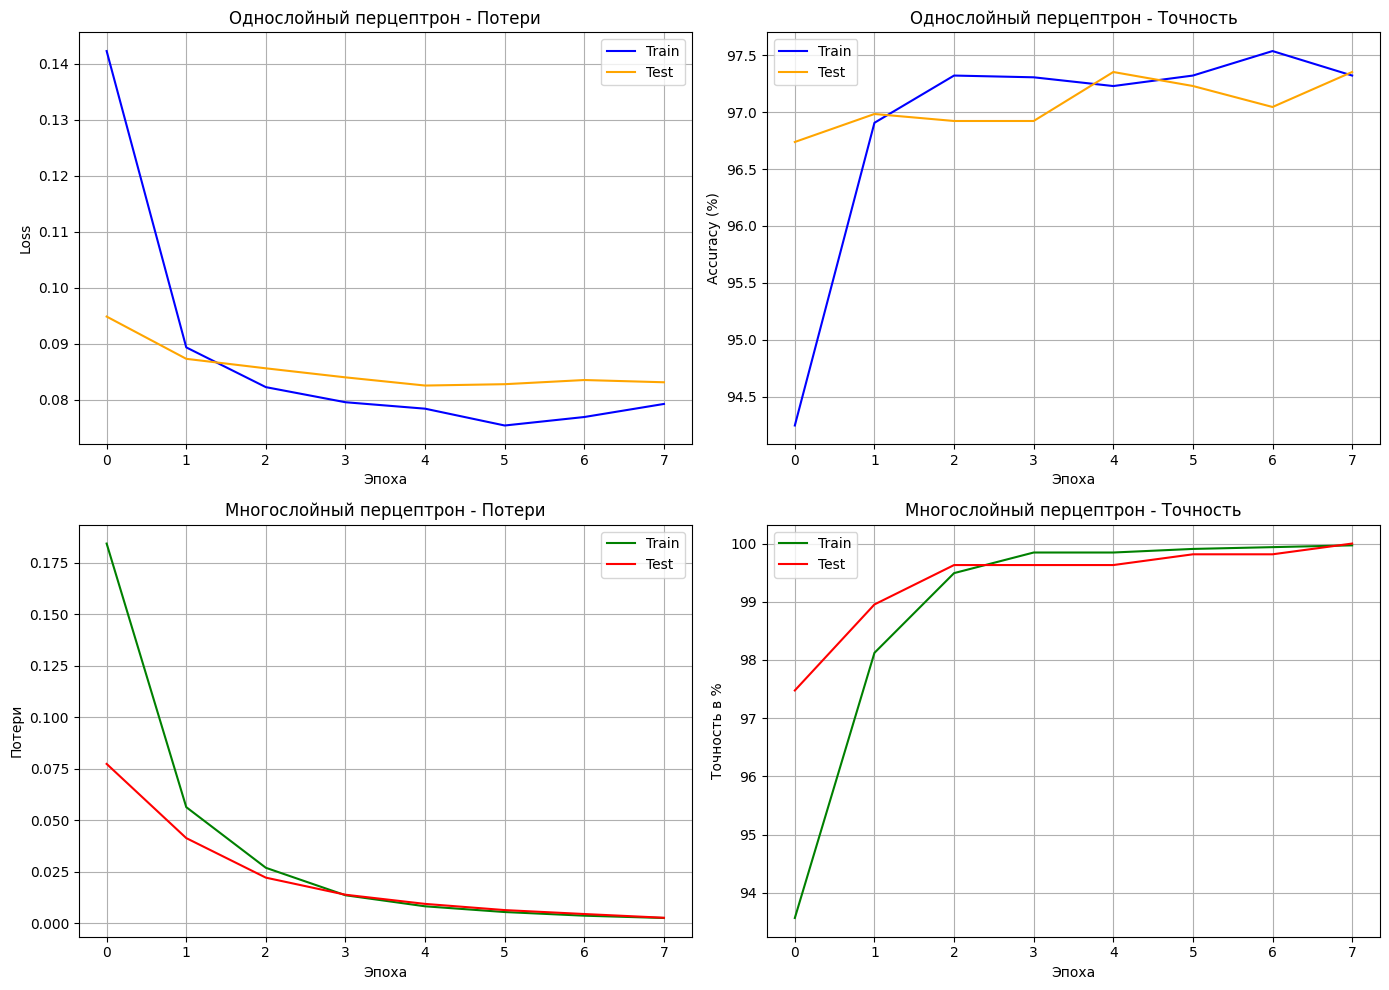

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Однослойный - потери
axes[0, 0].plot(ls_s, label='Train', color='blue')
axes[0, 0].plot(lt_s, label='Test', color='orange')
axes[0, 0].set_title('Однослойный перцептрон - Потери')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Однослойный - точность
axes[0, 1].plot(as_s, label='Train', color='blue')
axes[0, 1].plot(at_s, label='Test', color='orange')
axes[0, 1].set_title('Однослойный перцептрон - Точность')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Многослойный - потери
axes[1, 0].plot(ls_m, label='Train', color='green')
axes[1, 0].plot(lt_m, label='Test', color='red')
axes[1, 0].set_title('Многослойный перцептрон - Потери')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Потери')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Многослойный - точность
axes[1, 1].plot(as_m, label='Train', color='green')
axes[1, 1].plot(at_m, label='Test', color='red')
axes[1, 1].set_title('Многослойный перцептрон - Точность')
axes[1, 1].set_xlabel('Эпоха')
axes[1, 1].set_ylabel('Точность в %')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


Лучшая модель: Многослойный


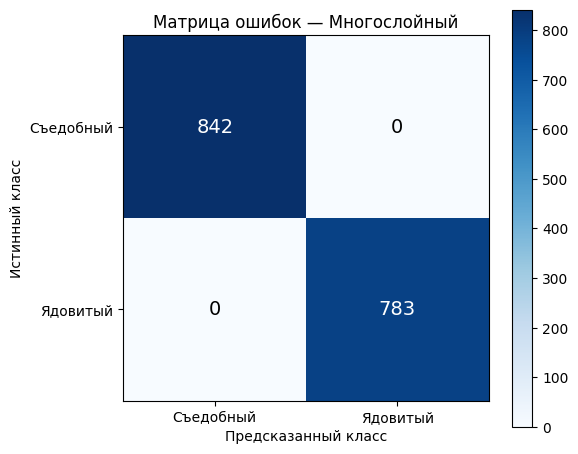


Точность на тесте: 100.00%


In [ ]:
# сравнение по точности моделей
# at_m[-1] и at_s[-1] — последнее значение в списке точностей, то есть точность после последней эпохи.
best_model = model_multi if at_m[-1] >= at_s[-1] else model_single
best_name  = "Многослойный" if at_m[-1] >= at_s[-1] else "Однослойный"
print(f"\nЛучшая модель: {best_name}")


# argmax(1) берет индекс максимальной оценки для каждого гриба — это и есть предсказанный класс (0 или 1).
# .cpu().numpy() преобразует тензор обратно в numpy для sklearn.
# eval() Переключает модель в режим оценки
best_model.eval()
with torch.no_grad():
    y_pred = best_model(X_test_t).argmax(1).cpu().numpy()


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title(f'Матрица ошибок — {best_name}')
plt.xticks([0, 1], ['Съедобный', 'Ядовитый'])
plt.yticks([0, 1], ['Съедобный', 'Ядовитый'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nТочность на тесте: {accuracy_score(y_test, y_pred)*100:.2f}%")
